### Load dependencies

In [1]:
import os
import pyciemss
import torch
import pandas as pd
import numpy as np
from typing import Dict, List, Callable

import pyciemss.visuals.plots as plots
import pyciemss.visuals.vega as vega
import pyciemss.visuals.trajectories as trajectories

from pyciemss.integration_utils.intervention_builder import (
    param_value_objective,
    start_time_objective,
    start_time_param_value_objective,
)

### Select a model

In [2]:
# MODEL_PATH = "https://raw.githubusercontent.com/DARPA-ASKEM/simulation-integration/main/data/models/"
# model1 = os.path.join(MODEL_PATH, "SIR_stockflow.json")
model1 = "SIR_stockflow.json"

## Simulate the model with no interventions

,timepoint_id,sample_id,timepoint_unknown,persistent_p_cbeta_param,persistent_p_tr_param,S_state,I_state,R_state
0,0,0,0.0,0.401252,11.572001,1000.000000,1.000000,0.000000
1,1,0,1.0,0.401252,11.572001,999.529114,1.369364,0.101542
2,2,0,2.0,0.401252,11.572001,998.884766,1.874742,0.240574
3,3,0,3.0,0.401252,11.572001,998.003723,2.565858,0.430889
4,4,0,4.0,0.401252,11.572001,996.799011,3.510296,0.691308


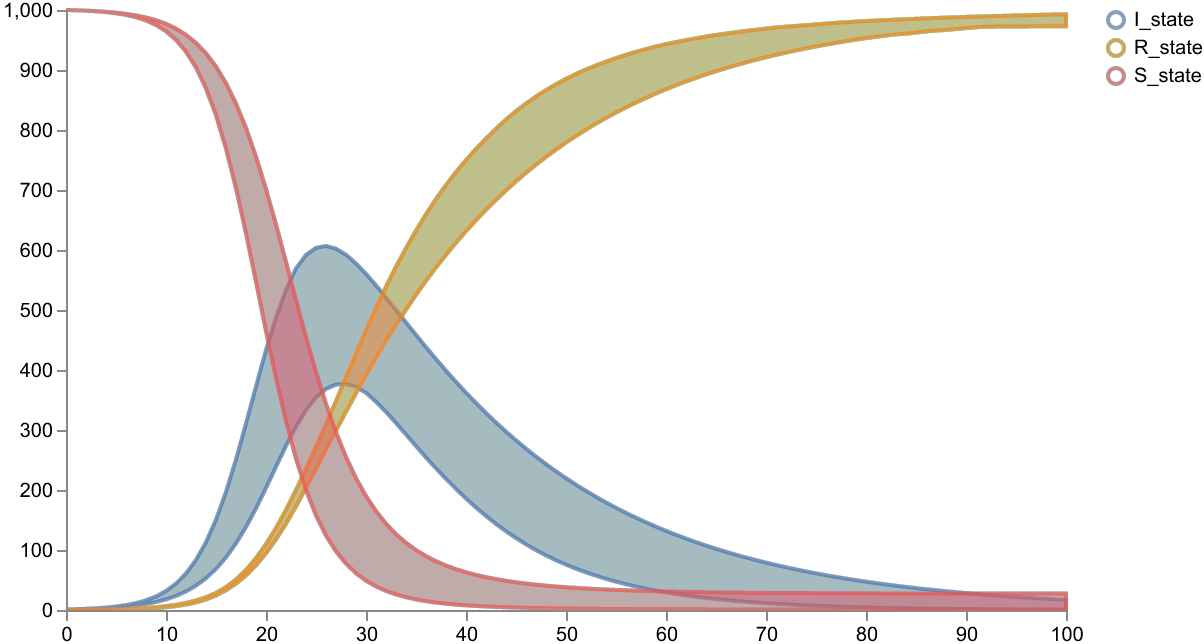

In [3]:
start_time = 0.0
end_time = 100.0
logging_step_size = 1.0
num_samples = 100

result1 = pyciemss.sample(model1, end_time, logging_step_size, num_samples, start_time=start_time)
display(result1['data'].head())

# Plot results for all states
schema = plots.trajectories(result1["data"], keep=".*_state")
plots.save_schema(schema, "_schema.json")
plots.ipy_display(schema, dpi=150)

In [4]:
num_samples = 1
end_time = 100.0

# Define the threshold for when the intervention should be applied
def make_var_threshold(var: str, threshold: torch.Tensor):
    previous_value = torch.tensor(1.1)

    def threshold_function(time, state):
        nonlocal previous_value
        if previous_value is torch.tensor(1.1):
            previous_value = state[var]
            return torch.tensor(1.0)  # On the first call, there's no previous value to compare to

        if previous_value < threshold <= state[var]:
            result = torch.tensor(0.0)  # Crosses from below
        elif previous_value > threshold >= state[var]:
            result = torch.tensor(1.0)  # Crosses from above
        else:
            result = torch.tensor(1.0)  # No crossing

        previous_value = state[var]
        return result

    return threshold_function


# Define the threshold for when the intervention should be applied
def make_var_threshold2(var: str, threshold: torch.Tensor):
    previous_value2 = torch.tensor(1.1)

    def threshold_function2(time, state):
        nonlocal previous_value2
        if previous_value2 is torch.tensor(1.1):
            previous_value2 = state[var]
            return torch.tensor(1.0)  # On the first call, there's no previous value to compare to

        if previous_value2 < threshold <= state[var]:
            result = torch.tensor(1.0)  # Crosses from below
        elif previous_value2 > threshold >= state[var]:
            result = torch.tensor(0.0)  # Crosses from above
        else:
            result = torch.tensor(1.0)  # No crossing

        previous_value2 = state[var]
        return result

    return threshold_function2

infection_threshold = make_var_threshold("I", torch.tensor(150.0))
infection_threshold2 = make_var_threshold2("I", torch.tensor(155.0))
# dynamic_parameter_interventions1 = {infection_threshold: {"p_cbeta": torch.tensor(0.3)},
#                                     infection_threshold2: {"p_cbeta": torch.tensor(0.45)}}

dynamic_parameter_interventions1 = {infection_threshold2: {"p_cbeta": torch.tensor(0.3)}}

result = pyciemss.sample(model1, end_time, logging_step_size, num_samples, start_time=start_time, 
                         dynamic_parameter_interventions=dynamic_parameter_interventions1, 
                         solver_method="dopri5")
display(result["data"].head())

# Plot the result
schema = plots.trajectories(pd.DataFrame(result["data"]), keep=".*_state")
plots.save_schema(schema, "_schema.json")
plots.ipy_display(schema, dpi=150)

ERROR:root:
                ###############################

                There was an exception in pyciemss

                Error occured in function: sample

                Function docs : 
    Load a model from a file, compile it into a probabilistic program, and sample from it.

    Args:
        model_path_or_json: Union[str, Dict]
            - A path to a AMR model file or JSON containing a model in AMR form.
        end_time: float
            - The end time of the sampled simulation.
        logging_step_size: float
            - The step size to use for logging the trajectory.
        num_samples: int
            - The number of samples to draw from the model.
        solver_method: str
            - The method to use for solving the ODE. See torchdiffeq's `odeint` method for more details.
            - If performance is incredibly slow, we suggest using `euler` to debug.
              If using `euler` results in faster simulation, the issue is likely that the model is s

RuntimeError: The solve terminated but no element of the event function output was within tolerance of zero.
                               Trace Shapes:  
                                Param Sites:  
numeric_deriv_func$$$_nodes.0._args.0._value  
numeric_deriv_func$$$_nodes.1._args.0._value  
                               Sample Sites:  
                     persistent_p_cbeta dist |
                                       value |
                        persistent_p_tr dist |
                                       value |

In [ ]:
schema = plots.trajectories(pd.DataFrame(result["data"]), keep="persistent_p_cbeta_param")
plots.save_schema(schema, "_schema.json")
plots.ipy_display(schema, dpi=150)